# Section 1 - Imports & Setup


### 1.1 - Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import random
import joblib
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True


### 1.2 - Path Setup and Data Loading

In [3]:
import sys
from pathlib import Path

# Define the Root (at SCANIA COMPONENT X)
PROJECT_ROOT = Path.cwd().parent

# Data Directory (Matches your "Data/Processed Data" folder exactly)
DATA_DIR = PROJECT_ROOT / "Data" / "Processed Data"

# Results Hierarchy
RESULTS_DIR = PROJECT_ROOT / "Results"
MODEL_DIR = RESULTS_DIR / "Models"
PREDICTION_DIR = RESULTS_DIR / "Predictions"

# Adding root to sys.path for imports
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Diagnostic Prints
print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Source:  {DATA_DIR}")
print(f"Model Path:   {MODEL_DIR}")
print(f"Predictions:  {PREDICTION_DIR}")

# Test if we can see the data file aka. if the path set-up is correct and the file exists
test_file = DATA_DIR / "val_processed.csv"
if test_file.exists():
    print(f"Success! Found {test_file}")
else:
    raise FileNotFoundError(f"Missing expected file: {test_file}")

Project Root: c:\Users\Elias\Documents\SCANIA Component X
Data Source:  c:\Users\Elias\Documents\SCANIA Component X\Data\Processed Data
Model Path:   c:\Users\Elias\Documents\SCANIA Component X\Results\Models
Predictions:  c:\Users\Elias\Documents\SCANIA Component X\Results\Predictions
Success! Found c:\Users\Elias\Documents\SCANIA Component X\Data\Processed Data\val_processed.csv


In [4]:
import importlib
import utils

importlib.reload(utils)

DEVICE = utils.DEVICE

if torch.cuda.is_available():
    print(f"Using CUDA at: {torch.cuda.get_device_name(0)}")
else:
    print("Warning. CUDA not avauilable. Using CPU, which may be slow for training.")

Using CUDA at: NVIDIA GeForce RTX 4060


### 1.3: Data Loading and Verification

In [5]:
# Importing the data files into pandas DataFrames. Skipping test_processed, as it will be used in the next notebook and not here.
train_data = pd.read_csv(DATA_DIR / 'train_processed.csv')
val_data   = pd.read_csv(DATA_DIR / 'val_processed.csv')

print("=== LOADED SUCCESSFULLY ===")
print(f"Training Data:   {train_data.shape}")
print(f"Validation Data: {val_data.shape}")


=== LOADED SUCCESSFULLY ===
Training Data:   (1122267, 108)
Validation Data: (196227, 108)


In [6]:
# Double checking the sizes of the loaded data and labels
print("=== Dataset Shapes ===")
print(f"Training Data: {train_data.shape}")
print(f"Validation Data: {val_data.shape}")
print('\n')

# Double cheking that no NaN values have snuck in
print("=== Checking for Missing values  ===")
print(f"Training Data: {train_data.isnull().sum().sum()}")
print(f"Validation Data: {val_data.isnull().sum().sum()}")
print('\n')

print("=== Label Distributions ===")
print(f"Train labels:\n{train_data['label'].value_counts()}")
print(f"Validation labels:\n{val_data['label'].value_counts()}")

train_data.head()


=== Dataset Shapes ===
Training Data: (1122267, 108)
Validation Data: (196227, 108)


=== Checking for Missing values  ===
Training Data: 0
Validation Data: 0


=== Label Distributions ===
Train labels:
label
0    1096527
1      25740
Name: count, dtype: int64
Validation labels:
label
0    191150
1      5077
Name: count, dtype: int64


,vehicle_id,time_step,label,171_0_delta,666_0_delta,427_0_delta,837_0_delta,167_0_delta,167_1_delta,167_2_delta,...,397_26_delta,397_27_delta,397_28_delta,397_29_delta,397_30_delta,397_31_delta,397_32_delta,397_33_delta,397_34_delta,397_35_delta
0,0,11.2,0,-0.849629,-0.749216,-0.885264,-0.605540,0.000000,-0.836789,-0.846661,...,-0.819951,-0.736580,-0.604093,-0.117108,-0.683286,-0.774069,-0.802742,-0.765314,-0.643327,-0.220868
1,0,11.4,0,-0.849629,-0.749216,-0.885264,-0.605540,0.076528,-0.215680,-0.846661,...,-0.764912,-0.671411,-0.604093,-0.117108,-0.683286,-0.774069,-0.748108,-0.765314,-0.643327,-0.220868
2,0,19.6,0,0.051073,0.058223,0.038719,-0.007914,0.000000,-0.836789,-0.846661,...,0.034572,0.034710,0.024414,0.154808,0.094829,0.140798,0.052528,0.050453,0.014113,-0.220868
3,0,20.2,0,-0.095038,-0.141034,-0.078776,-0.309542,0.000000,-0.836789,-0.846661,...,-0.109708,-0.139971,-0.152043,-0.117108,-0.295374,-0.033225,-0.125102,-0.150487,-0.225831,-0.125745
4,0,21.0,0,-0.154429,-0.195811,-0.119957,-0.119320,0.000000,-0.836789,-0.846661,...,-0.138285,-0.115177,-0.223147,-0.117108,-0.599754,-0.125981,-0.129902,-0.122774,-0.202997,-0.125745


# Section 2 - Data Input Preparation



### 2.1 - Inspecting the Data on how to arrange the sequence inputs based on its shape

In [7]:
# Checking the statistics of the overall training data
seq_lengths = train_data.groupby('vehicle_id')['time_step'].count()
seq_lengths.describe()

count    23540.000000
mean        47.674894
std         27.403192
min          5.000000
25%         28.000000
50%         43.000000
75%         64.000000
max        303.000000
Name: time_step, dtype: float64

In [8]:
# Checking the statistics of the failed classes from the training data
failed_vehicles = train_data[train_data['label'] == 1]['vehicle_id'].unique()
seq_lengths[failed_vehicles].describe()

count    2262.00000
mean       46.71397
std        24.11327
min         5.00000
25%        29.00000
50%        43.00000
75%        60.75000
max       236.00000
Name: time_step, dtype: float64

The distribution of the failed classes and the overall data seems to follow the same distribution, which could also bee seen in the Data preparation Notebook dring the EDA. For us, this means that we can pick a sequence size that follows this distribution. Since the most recent readings are most informative for failure prediction, sequences longer than the N timesteps chosen will be truncated and keeping the m last entries. Sequences that are shorter will be padded with zeros at the begining of their sequence. The chosen length is initialized below.

In [9]:
SEQ_LEN = 50

### 2.2 - Generating the Input Data

In [10]:
# Printing Statistical information Before the Sequential Data Creation, exluding the non-feature columns
feature_cols = [c for c in train_data.columns if c not in ['vehicle_id', 'time_step', 'label']]
print(f"Train mean: {train_data[feature_cols].mean().mean():.3f}, std: {train_data[feature_cols].std().mean():.3f}")
print(f"Val mean:   {val_data[feature_cols].mean().mean():.3f}, std: {val_data[feature_cols].std().mean():.3f}")

Train mean: -0.037, std: 0.226
Val mean:   0.023, std: 0.243


In [11]:
# For the LR data
X_train_lr, y_train_lr = utils.prepare_lr_data(train_data, 'label')
X_val_lr, y_val_lr = utils.prepare_lr_data(val_data, 'label')

# For the sequential data
X_train_seq, y_train_seq, train_seq_ids = utils.generate_sequential_data(train_data, 'label', SEQ_LEN)
X_val_seq, y_val_seq, val_seq_ids = utils.generate_sequential_data(val_data, 'label', SEQ_LEN)

INPUT_SIZE = X_train_seq.shape[2]

In [12]:
# Printing Statistical information on the Sequential Data
print("=== Statistical Properites Seq Data ===")
print(f"Train mean: {X_train_seq.mean():.3f}, std: {X_train_seq.std():.3f}")
print(f"Val mean:   {X_val_seq.mean():.3f}, std: {X_val_seq.std():.3f}")

=== Statistical Properites Seq Data ===
Train mean: -0.018, std: 0.224
Val mean:   0.024, std: 0.226


# Section 3 - Model Training

## 3.1 - Logistic Regression

### 3.1.1 - Logistic Regression Functions

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve


def train_lr_model(X, y):
  lr_model = LogisticRegression(
    penalty='elasticnet',      
    l1_ratio=0.5,              
    C=5.0, 
    solver='saga',             
    class_weight='balanced', 
    random_state=SEED, 
    max_iter=1000
)

  lr_model.fit(X, y)

  return lr_model

def get_lr_predictions(model, X):
  predictions = model.predict(X)
  probabilities = model.predict_proba(X)[:,1]

  return predictions, probabilities

def save_lr_predictions(X, predictions, probabilities, path):
  vehicle = X.index.values

  predictions_df = pd.DataFrame({
      'vehicle_id': vehicle,
      'probability': probabilities,
      'binary_prediction': predictions
  })

  print("Saving the DataFrame...")
  predictions_df.to_csv(path, index=False)
  print(f"DataFrame saved to {path}")

  return None

def save_lr_model(model, path):
  print("Saving the model...")
  joblib.dump(model, path)
  print(f"Model saved to {path}")

  return None


def plot_learning_curve(estimator, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, scoring='f1', n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training F1 Score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation F1 Score")
    
    plt.title("Learning Curve")
    plt.xlabel("Training examples")
    plt.ylabel("F1 Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()


### 3.1.2 -  Training & Evaluation

In [66]:
# Train
lr_model = train_lr_model(X_train_lr, y_train_lr)

# Predict
pred, prob = get_lr_predictions(lr_model, X_val_lr)

# Evaluate — use the same metrics as BaseTrainer for consistency
lr_metrics = {
    'Recall': recall_score(y_val_lr, pred),
    'Precision': precision_score(y_val_lr, pred),
    'F1': f1_score(y_val_lr, pred),
    'AUC-ROC': roc_auc_score(y_val_lr, prob),
    'AUC-PR': average_precision_score(y_val_lr, prob),
}

print("___________________________________________")
print("Standard Metrics:")
print(lr_metrics)
# Prediction distribution
print(f"\nPrediction distribution:\n{pd.Series(pred).value_counts()}")

c:\Users\Elias\Documents\SCANIA Component X\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


___________________________________________
Standard Metrics:
{'Recall': 0.75, 'Precision': 0.0399529964747356, 'F1': 0.0758646336928226, 'AUC-ROC': 0.6925467233736672, 'AUC-PR': 0.06472961080666186}

Prediction distribution:
1    2553
0    2493
Name: count, dtype: int64


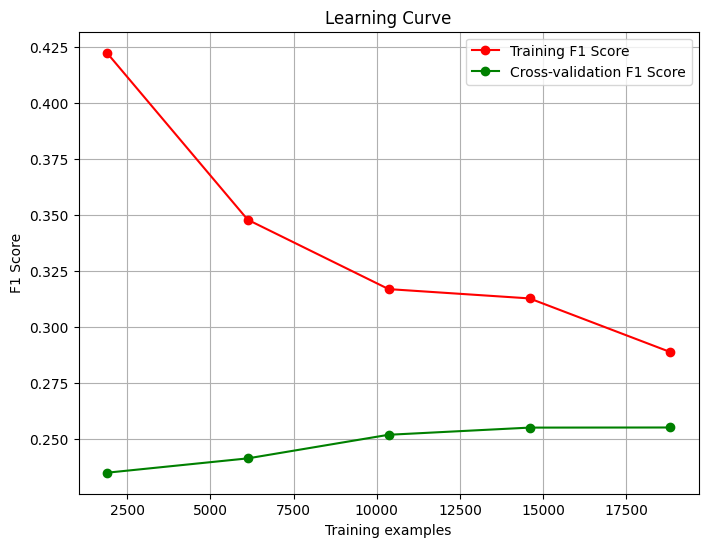

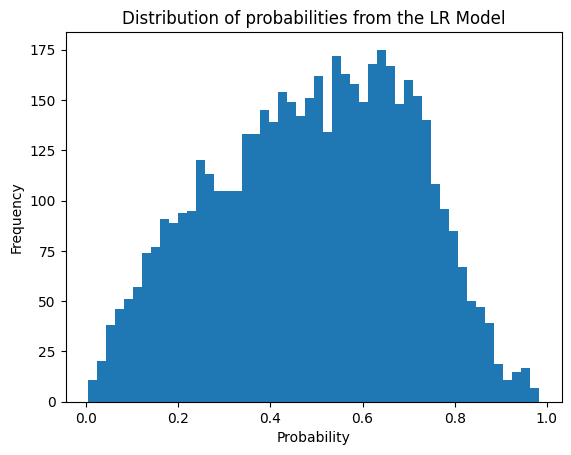

In [67]:
plot_learning_curve(lr_model, X_train_lr, y_train_lr)

# Histogram
plt.hist(prob, bins=50)
plt.title('Distribution of probabilities from the LR Model')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.show()

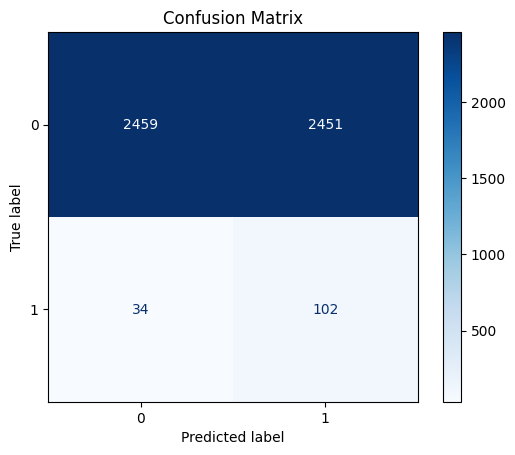

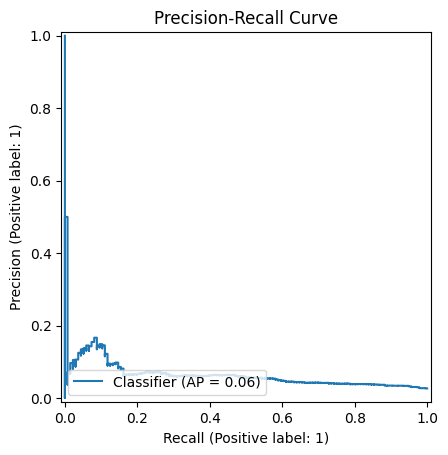

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import PrecisionRecallDisplay


# Using the predictions you already generated
ConfusionMatrixDisplay.from_predictions(y_val_lr, pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


PrecisionRecallDisplay.from_predictions(y_val_lr, prob)
plt.title("Precision-Recall Curve")
plt.show()

#### **Summary**
The LR Model was trained on the last timestep of each of the vehicle's readouts usint `class_weight = 'balanced'` to account for the severe class imbalance in the data set. The ratio between recall and precision as well as AUC ROC vs PR tells us that the model was able to gain some separability on the classes, but is far from stron. The distribution is concentrated around 0.5 which tells us it is a little better than randomly assigning the labels.

Furthermore, the aggressive class weighting also caused the model to flag nearly half of all vehicles as potential failures. It would probably be worse off overall if we did not include it, since false negatives are our biggest concern, however it indicates that the model is far from usable in rea industrial maintanance settings.

In conclusion, we have experienced expected behaviour from this model. THe Logisitic Regression is used only as a baseline model that is trained on the heavily imbalanced data set. The main goal here is to serve as a reference against LSTM / TCN but as well as data augmentation methods.

## 3.2 -  LSTM

### 3.2.1 -  Hyperparameters

In [38]:
HIDDEN_SIZE = 32
NUM_LAYERS = 1
LEARNING_RATE = 0.00001
BATCH_SIZE = 64
NUM_EPOCHS = 1000
PATIENCE = 15
DROPOUT = 0.5
CLIP_GRAD = 1.0

### 3.2.3 - Model Training

In [39]:
# Creating the Model
lstm = utils.LSTMModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

# Creating the Trainer
lstm_trainer = utils.BaseTrainer(
    model=lstm,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    clip_grad=CLIP_GRAD
)

In [40]:
# Fitting on the training data and validating on the validation data, with early stopping and model checkpointing.
lstm_trainer.fit(
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_path=MODEL_DIR / 'lstm_model_best.pt'
);

Epoch 1/1000 - Time: 1.86s - Train: 0.0431 - Val: 0.0364 - Val AUC-PR: 0.0366
___________________________________
Epoch 2/1000 - Time: 1.64s - Train: 0.0411 - Val: 0.0342 - Val AUC-PR: 0.0471
___________________________________
Epoch 3/1000 - Time: 1.67s - Train: 0.0396 - Val: 0.0325 - Val AUC-PR: 0.0482
___________________________________
Epoch 4/1000 - Time: 1.67s - Train: 0.0385 - Val: 0.0311 - Val AUC-PR: 0.0476
___________________________________
Epoch 5/1000 - Time: 1.66s - Train: 0.0377 - Val: 0.0299 - Val AUC-PR: 0.0478
___________________________________
Epoch 6/1000 - Time: 1.63s - Train: 0.0371 - Val: 0.0288 - Val AUC-PR: 0.0478
___________________________________
Epoch 7/1000 - Time: 1.62s - Train: 0.0368 - Val: 0.0280 - Val AUC-PR: 0.0484
___________________________________
Epoch 8/1000 - Time: 1.61s - Train: 0.0365 - Val: 0.0273 - Val AUC-PR: 0.0493
___________________________________
Epoch 9/1000 - Time: 1.62s - Train: 0.0362 - Val: 0.0267 - Val AUC-PR: 0.0501
__________

### 3.2.4 -  Evaluation

___________________________________________
Standard Metrics:
Recall      : 0.2574
Precision   : 0.0753
F1          : 0.1165
AUC-ROC     : 0.6616
AUC-PR      : 0.0638


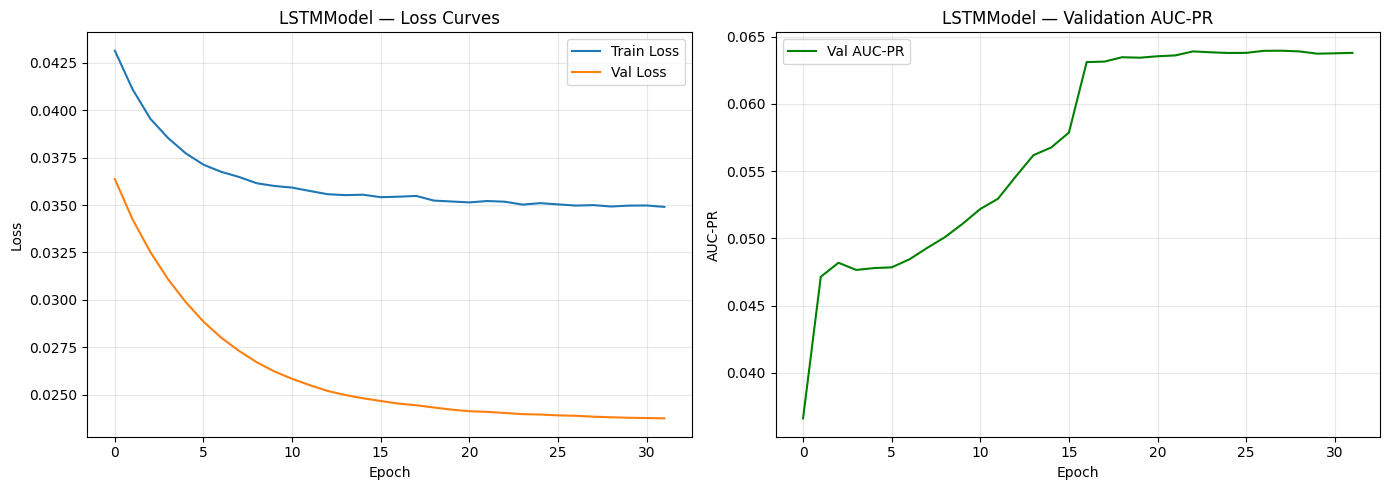

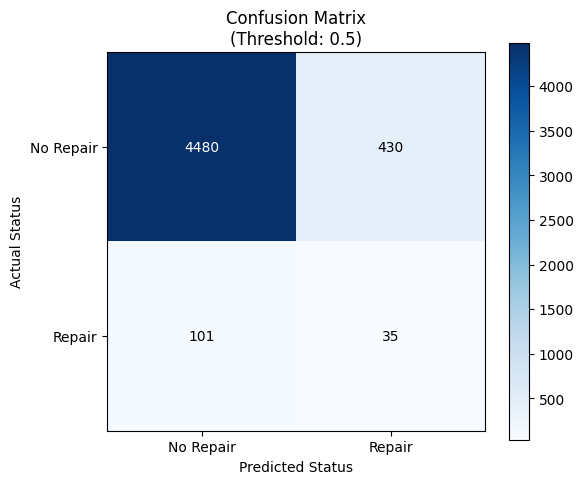

In [41]:
lstm_trainer.evaluate(X_val_seq, y_val_seq)
lstm_trainer.plot_history()
lstm_trainer.plot_cm(X_val_seq, y_val_seq)

In [42]:
import numpy as np
import pandas as pd


PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'Data' / 'Processed Data'
test_data   = pd.read_csv(DATA_DIR / 'test_processed.csv')

SCANIA_COST = {
    (0,0):0,   (0,1):7,   (0,2):8,   (0,3):9,   (0,4):10,
    (1,0):200, (1,1):0,   (1,2):7,   (1,3):8,   (1,4):9,
    (2,0):300, (2,1):200, (2,2):0,   (2,3):7,   (2,4):8,
    (3,0):400, (3,1):300, (3,2):200, (3,3):0,   (3,4):7,
    (4,0):500, (4,1):400, (4,2):300, (4,3):200, (4,4):0,
}

# VAL — tune
_, probs_val = lstm_trainer.predict(X_val_seq)
val_labels = pd.read_csv(PROJECT_ROOT / 'Data' / 'validation_labels.csv')
val_class = val_labels.set_index('vehicle_id').loc[val_seq_ids, 'class_label'].values

best_cost, best_t = float('inf'), 0.5
for t in np.arange(0.05, 0.95, 0.01):
    pred = (probs_val >= t).astype(int) * 4
    cost = sum(SCANIA_COST[(int(yt), int(yp))] for yt, yp in zip(val_class, pred))
    if cost < best_cost:
        best_cost, best_t = cost, t

print(f"VAL — best threshold: {best_t:.2f}")
print(f"VAL — cost per vehicle: {best_cost/len(val_class):.2f}")

# TEST — apply
X_test_seq, y_test_seq, test_seq_ids = utils.generate_sequential_data(test_data, 'label', SEQ_LEN)
_, probs_test = lstm_trainer.predict(X_test_seq)
test_labels = pd.read_csv(PROJECT_ROOT / 'Data' / 'test_labels.csv')
test_class = test_labels.set_index('vehicle_id').loc[test_seq_ids, 'class_label'].values

pred_test = (probs_test >= best_t).astype(int) * 4
cost_test = sum(SCANIA_COST[(int(yt), int(yp))] for yt, yp in zip(test_class, pred_test))

print(f"TEST — threshold: {best_t}")
print(f"TEST — cost per vehicle: {cost_test/len(test_class):.2f}")

VAL — best threshold: 0.46
VAL — cost per vehicle: 7.97
TEST — threshold: 0.4600000000000001
TEST — cost per vehicle: 7.93


## 3.3 - TCN

### 3.3.1 -  Hyperparameters

In [57]:
TCN_NUM_CHANNELS = 64
TCN_KERNEL_SIZE = 3
TCN_NUM_LAYERS = 2
TCN_LEARNING_RATE = 0.00001
TCN_BATCH_SIZE = 128
TCN_DROPOUT = 0.5
TCN_NUM_EPOCHS = 1000
TCN_PATIENCE = 10

### 3.3.2 -  Model Training

In [58]:
# Creating the TCN model
tcn = utils.TCNModel(
    input_size=INPUT_SIZE,
    num_channels=TCN_NUM_CHANNELS,
    num_layers=TCN_NUM_LAYERS,
    kernel_size=TCN_KERNEL_SIZE,
    dropout=TCN_DROPOUT
)

# Creating the TCN trainer
tcn_trainer = utils.BaseTrainer(
    model=tcn,
    lr=TCN_LEARNING_RATE,
    batch_size=TCN_BATCH_SIZE,
    clip_grad=None
)



In [59]:
# Fitting on the training data and validating on the validation data, with early stopping and model checkpointing.
tcn_trainer.fit(
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    num_epochs=TCN_NUM_EPOCHS,
    patience=TCN_PATIENCE,
    save_path=MODEL_DIR / 'tcn_model_best.pt'
);

Epoch 1/1000 - Time: 24.62s - Train: 0.0847 - Val: 0.0475 - Val AUC-PR: 0.0269
___________________________________
Epoch 2/1000 - Time: 24.77s - Train: 0.0690 - Val: 0.0359 - Val AUC-PR: 0.0290
___________________________________
Epoch 3/1000 - Time: 25.50s - Train: 0.0607 - Val: 0.0299 - Val AUC-PR: 0.0310
___________________________________
Epoch 4/1000 - Time: 25.25s - Train: 0.0567 - Val: 0.0268 - Val AUC-PR: 0.0325
___________________________________
Epoch 5/1000 - Time: 25.74s - Train: 0.0549 - Val: 0.0248 - Val AUC-PR: 0.0337
___________________________________
Epoch 6/1000 - Time: 25.62s - Train: 0.0521 - Val: 0.0234 - Val AUC-PR: 0.0353
___________________________________
Epoch 7/1000 - Time: 25.07s - Train: 0.0513 - Val: 0.0231 - Val AUC-PR: 0.0368
___________________________________
Epoch 8/1000 - Time: 25.28s - Train: 0.0505 - Val: 0.0224 - Val AUC-PR: 0.0377
___________________________________
Epoch 9/1000 - Time: 25.50s - Train: 0.0492 - Val: 0.0221 - Val AUC-PR: 0.0392
_

### 3.3.3 -  Evaluation

___________________________________________
Standard Metrics:
Recall      : 0.4044
Precision   : 0.0498
F1          : 0.0887
AUC-ROC     : 0.6759
AUC-PR      : 0.0545


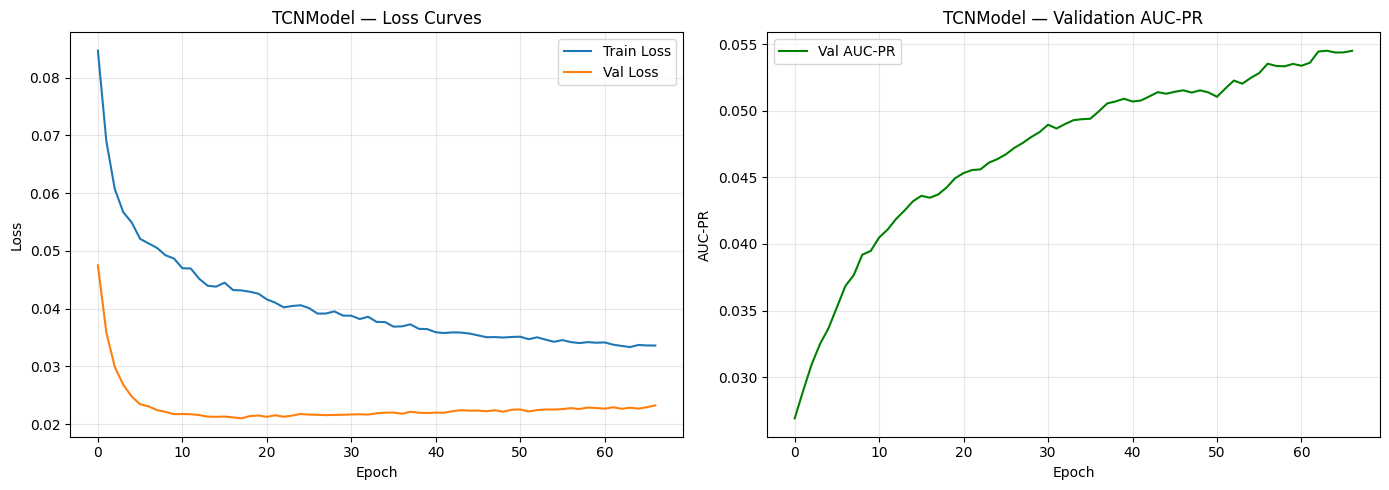

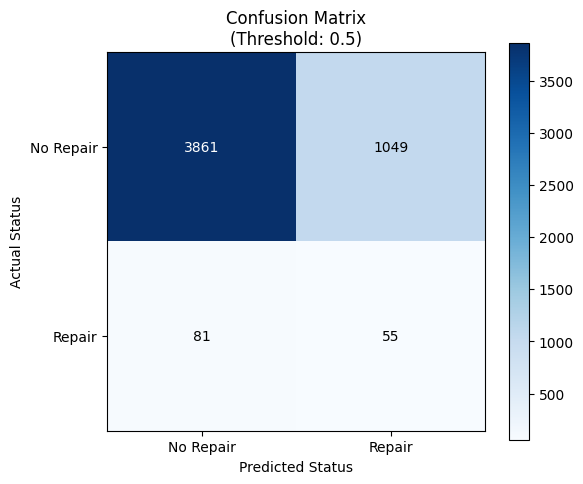

In [60]:
# Evaluating the TCN model on the validation set and plotting the results
tcn_trainer.evaluate(X_val_seq, y_val_seq)
tcn_trainer.plot_history()
tcn_trainer.plot_cm(X_val_seq, y_val_seq)

## 3.4  - Deep Learning Model Comparison

In [61]:
lstm_metrics, lstm_preds, lstm_probs = lstm_trainer.evaluate(X_val_seq, y_val_seq);
tcn_metrics, tcn_preds, tcn_probs = tcn_trainer.evaluate(X_val_seq, y_val_seq);

comparison = pd.DataFrame({
    'LSTM': lstm_metrics,
    'TCN': tcn_metrics,
});
print(comparison.round(4))

___________________________________________
Standard Metrics:
Recall      : 0.2574
Precision   : 0.0753
F1          : 0.1165
AUC-ROC     : 0.6616
AUC-PR      : 0.0638
___________________________________________
Standard Metrics:
Recall      : 0.4044
Precision   : 0.0498
F1          : 0.0887
AUC-ROC     : 0.6759
AUC-PR      : 0.0545
             LSTM     TCN
Recall     0.2574  0.4044
Precision  0.0753  0.0498
F1         0.1165  0.0887
AUC-ROC    0.6616  0.6759
AUC-PR     0.0638  0.0545


# Section 4 - Data Augmentation

## 4.1 - Applying TapNet on the Data

In [82]:
from sktime.classification.deep_learning.tapnet import TapNetClassifier
from imblearn.over_sampling import SMOTE
import tensorflow

# 1. Reshape for sktime: (n_samples, n_features, seq_len)
X_train_sktime = np.swapaxes(X_train_seq, 1, 2)
X_val_sktime   = np.swapaxes(X_val_seq, 1, 2)
X_test_sktime  = np.swapaxes(X_test_seq, 1, 2)

# 2. Train on 85% slice
split = int(0.85 * len(X_train_sktime))
tapnet_model = TapNetClassifier(
    n_epochs=30,
    batch_size=32,
    random_state=42,
    verbose=True
)
tapnet_model.fit(X_train_sktime[:split], y_train_seq[:split])

# 3. Extract embeddings from penultimate layer
from tensorflow.keras.models import Model
keras_model = tapnet_model.model_
feature_extractor = Model(
    inputs=keras_model.input,
    outputs=keras_model.get_layer('fc_2').output
)

X_train_emb = feature_extractor.predict(np.swapaxes(X_train_sktime, 1, 2), batch_size=64)
X_val_emb   = feature_extractor.predict(np.swapaxes(X_val_sktime, 1, 2), batch_size=64)
X_test_emb  = feature_extractor.predict(np.swapaxes(X_test_sktime, 1, 2), batch_size=64)

# 4. SMOTE on embeddings
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_emb, y_train_seq)

print(f"Before SMOTE: {dict(zip(*np.unique(y_train_seq, return_counts=True)))}")
print(f"After SMOTE:  {dict(zip(*np.unique(y_resampled, return_counts=True)))}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 50, 106)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 50, 33)    │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 50, 33)    │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 50, 256)   │     67,840 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 50, 256)   │     67,840 │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 50, 33)    │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 256)   │      1,024 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 256)   │      1,024 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 50, 256)   │     67,840 │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 50, 256)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 50, 256)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 256)   │      1,024 │ conv1d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 50, 256)   │    524,544 │ activation_10[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 50, 256)   │    524,544 │ activation_13[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 50, 256)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 256)   │      1,024 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 256)   │      1,024 │ conv1d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 50, 256)   │    524,544 │ activation_16[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 50, 256)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 50, 256)   │          0 │ batch_normalizat

 Total params: 3,166,910 (12.08 MB)

 Trainable params: 3,162,070 (12.06 MB)

 Non-trainable params: 4,840 (18.91 KB)

Epoch 1/30
626/626 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.8811 - loss: 0.4379
Epoch 2/30
626/626 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.8907 - loss: 0.3557
Epoch 3/30
626/626 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.8927 - loss: 0.3353
Epoch 4/30
626/626 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.8932 - loss: 0.3256
Epoch 5/30
626/626 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.8932 - loss: 0.3231
Epoch 6/30
626/626 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.8935 - loss: 0.3209
Epoch 7/30
626/626 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.8933 - loss: 0.3221
Epoch 8/30
626/626 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.8929 - loss: 0.3232
Epoch 9/30
626/626 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.8929 - loss: 0.3240
Epoch 10/30
626/626 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.8928 - loss: 0.3272
Epoch 11/30
626/626 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.8935 - loss: 0.3259
Epoch 12/30
626/626 ━━━━━━━━━━

## 4.2 - Training Classifiers on SMOTE-Augmented TapNet Embeddings

In [83]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

# LR on SMOTE embeddings
smote_lr = LogisticRegression(C=5.0, solver='saga', max_iter=1000, random_state=42)
smote_lr.fit(X_resampled, y_resampled)
smote_lr_probs = smote_lr.predict_proba(X_val_emb)[:, 1]
smote_lr_preds = (smote_lr_probs >= 0.5).astype(int)
print(f"SMOTE+LR AUC-PR: {average_precision_score(y_val_seq, smote_lr_probs):.4f}")

# XGBoost on SMOTE embeddings
smote_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42,
    eval_metric='aucpr'
)
smote_xgb.fit(X_resampled, y_resampled)
smote_xgb_probs = smote_xgb.predict_proba(X_val_emb)[:, 1]
smote_xgb_preds = (smote_xgb_probs >= 0.5).astype(int)
print(f"SMOTE+XGB AUC-PR: {average_precision_score(y_val_seq, smote_xgb_probs):.4f}")

c:\Users\Elias\Documents\SCANIA Component X\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


SMOTE+LR AUC-PR: 0.0706
SMOTE+XGB AUC-PR: 0.0445


In [96]:
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score

smote_lr_probs_val = smote_lr.predict_proba(X_val_emb)[:, 1]
smote_lr_preds_val = (smote_lr_probs_val >= 0.5).astype(int)

smote_xgb_probs_val = smote_xgb.predict_proba(X_val_emb)[:, 1]
smote_xgb_preds_val = (smote_xgb_probs_val >= 0.5).astype(int)

smote_lr_metrics = {
    'Recall':    recall_score(y_val_seq, smote_lr_preds_val),
    'Precision': precision_score(y_val_seq, smote_lr_preds_val),
    'F1':        f1_score(y_val_seq, smote_lr_preds_val),
    'AUC-ROC':   roc_auc_score(y_val_seq, smote_lr_probs_val),
    'AUC-PR':    average_precision_score(y_val_seq, smote_lr_probs_val),
}

smote_xgb_metrics = {
    'Recall':    recall_score(y_val_seq, smote_xgb_preds_val),
    'Precision': precision_score(y_val_seq, smote_xgb_preds_val),
    'F1':        f1_score(y_val_seq, smote_xgb_preds_val),
    'AUC-ROC':   roc_auc_score(y_val_seq, smote_xgb_probs_val),
    'AUC-PR':    average_precision_score(y_val_seq, smote_xgb_probs_val),
}



## 4.3 - Comparison Across All Models

=== Comparison of all models===
               LR    LSTM     TCN  SMOTE+LR  SMOTE+XGB
Recall     0.7500  0.2574  0.4044    0.8088     0.5735
Precision  0.0400  0.0753  0.0498    0.0392     0.0363
F1         0.0759  0.1165  0.0887    0.0749     0.0683
AUC-ROC    0.6925  0.6616  0.6759    0.6856     0.6241
AUC-PR     0.0647  0.0638  0.0545    0.0706     0.0445


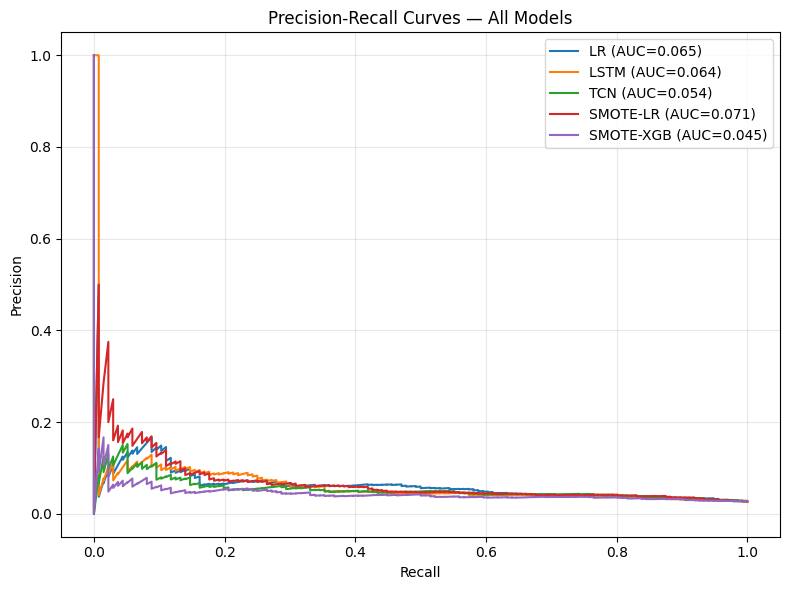

In [97]:
from sklearn.metrics import precision_recall_curve


# A quick check on model performance comparison
comparison_default = pd.DataFrame({
    'LR': lr_metrics,
    'LSTM': lstm_metrics,
    'TCN': tcn_metrics,
    'SMOTE+LR': smote_lr_metrics,
    'SMOTE+XGB': smote_xgb_metrics,
})
print("=== Comparison of all models===")
print(comparison_default.round(4))


plt.figure(figsize=(8, 6))

models = {
    'LR': (prob, y_val_lr),
    'LSTM': (lstm_probs, y_val_seq),
    'TCN': (tcn_probs, y_val_seq),
    'SMOTE-LR': (smote_lr_probs_val, y_val_seq),
    'SMOTE-XGB': (smote_xgb_probs_val , y_val_seq),
}

for name, (probs, y_true) in models.items():
    precision, recall, _ = precision_recall_curve(y_true, probs)
    auc = average_precision_score(y_true, probs)
    plt.plot(recall, precision, label=f'{name} (AUC={auc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Section 5 Hyperparameter Tuning 

## 5.1 - Randomized Search on LSTM and TCN
These models were made with PyTorch, as such they do not follow Sklearn API meaning we need to do a manual random search. 

### 5.1.1 - LSTM 

In [31]:
lstm_param_grid = {
    'hidden_size': [8, 16, 32, 64, 128],
    'num_layers':  [1, 2, 3],
    'dropout':     [0.1, 0.2, 0.3, 0.4, 0.5],
    'lr':          [0.00001, 0.0001, 0.0005, 0.001, 0.005, 0.01]
}

N_ITER_LSTM = 20


# LSTM
best_lstm_params, best_lstm_auc_pr, lstm_results = utils.random_search(
    model_class=utils.LSTMModel,
    param_grid=lstm_param_grid,
    model_kwargs_fn=lambda p: {
        'input_size':   INPUT_SIZE,
        'hidden_size':  p['hidden_size'],
        'num_layers':   p['num_layers'],
        'dropout':      p['dropout']
    },
    X_train=X_train_seq, y_train=y_train_seq,
    X_val=X_val_seq,     y_val=y_val_seq,
    n_iter=N_ITER_LSTM,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_dir=MODEL_DIR,
    model_name='lstm',
    clip_grad=CLIP_GRAD
)



Trial 1/20: {'hidden_size': 8, 'num_layers': 1, 'dropout': 0.3, 'lr': 0.0001}
Epoch 1/1000 - Time: 2.93s - Train: 0.0370 - Val: 0.0230 - Val AUC-PR: 0.0338
___________________________________
Epoch 2/1000 - Time: 2.77s - Train: 0.0365 - Val: 0.0228 - Val AUC-PR: 0.0361
___________________________________
Epoch 3/1000 - Time: 2.75s - Train: 0.0360 - Val: 0.0230 - Val AUC-PR: 0.0395
___________________________________
Epoch 4/1000 - Time: 2.75s - Train: 0.0358 - Val: 0.0233 - Val AUC-PR: 0.0438
___________________________________
Epoch 5/1000 - Time: 2.71s - Train: 0.0354 - Val: 0.0230 - Val AUC-PR: 0.0448
___________________________________
Epoch 6/1000 - Time: 2.75s - Train: 0.0350 - Val: 0.0229 - Val AUC-PR: 0.0454
___________________________________
Epoch 7/1000 - Time: 2.77s - Train: 0.0348 - Val: 0.0229 - Val AUC-PR: 0.0509
___________________________________
Epoch 8/1000 - Time: 2.74s - Train: 0.0343 - Val: 0.0232 - Val AUC-PR: 0.0538
___________________________________
Epoch 9/1

c:\Users\Elias\Documents\SCANIA Component X\utils\trainer.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(save_path, map_location

Epoch 1/1000 - Time: 2.74s - Train: 0.0356 - Val: 0.0252 - Val AUC-PR: 0.0313
___________________________________
Epoch 2/1000 - Time: 2.75s - Train: 0.0355 - Val: 0.0230 - Val AUC-PR: 0.0411
___________________________________
Epoch 3/1000 - Time: 2.73s - Train: 0.0354 - Val: 0.0227 - Val AUC-PR: 0.0327
___________________________________
Epoch 4/1000 - Time: 2.72s - Train: 0.0354 - Val: 0.0243 - Val AUC-PR: 0.0480
___________________________________
Epoch 5/1000 - Time: 2.73s - Train: 0.0354 - Val: 0.0212 - Val AUC-PR: 0.0494
___________________________________
Epoch 6/1000 - Time: 2.72s - Train: 0.0353 - Val: 0.0238 - Val AUC-PR: 0.0450
___________________________________
Epoch 7/1000 - Time: 2.71s - Train: 0.0354 - Val: 0.0279 - Val AUC-PR: 0.0313
___________________________________
Epoch 8/1000 - Time: 2.74s - Train: 0.0355 - Val: 0.0231 - Val AUC-PR: 0.0418
___________________________________
Epoch 9/1000 - Time: 2.71s - Train: 0.0353 - Val: 0.0240 - Val AUC-PR: 0.0547
__________

c:\Users\Elias\Documents\SCANIA Component X\utils\trainer.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(save_path, map_location

Epoch 1/1000 - Time: 2.66s - Train: 0.0347 - Val: 0.0230 - Val AUC-PR: 0.0540
___________________________________
Epoch 2/1000 - Time: 2.59s - Train: 0.0341 - Val: 0.0251 - Val AUC-PR: 0.0490
___________________________________
Epoch 3/1000 - Time: 2.62s - Train: 0.0341 - Val: 0.0256 - Val AUC-PR: 0.0533
___________________________________
Epoch 4/1000 - Time: 2.59s - Train: 0.0339 - Val: 0.0229 - Val AUC-PR: 0.0522
___________________________________
Epoch 5/1000 - Time: 2.57s - Train: 0.0338 - Val: 0.0266 - Val AUC-PR: 0.0626
___________________________________
Epoch 6/1000 - Time: 3.14s - Train: 0.0337 - Val: 0.0238 - Val AUC-PR: 0.0551
___________________________________
Epoch 7/1000 - Time: 2.75s - Train: 0.0335 - Val: 0.0251 - Val AUC-PR: 0.0532
___________________________________
Epoch 8/1000 - Time: 2.86s - Train: 0.0336 - Val: 0.0240 - Val AUC-PR: 0.0559
___________________________________
Epoch 9/1000 - Time: 2.74s - Train: 0.0336 - Val: 0.0246 - Val AUC-PR: 0.0606
__________

...

c:\Users\Elias\Documents\SCANIA Component X\utils\trainer.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(save_path, map_location

Epoch 1/1000 - Time: 3.29s - Train: 0.0362 - Val: 0.0246 - Val AUC-PR: 0.0270
___________________________________
Epoch 2/1000 - Time: 3.30s - Train: 0.0362 - Val: 0.0237 - Val AUC-PR: 0.0270
___________________________________
Epoch 3/1000 - Time: 3.29s - Train: 0.0362 - Val: 0.0247 - Val AUC-PR: 0.0270
___________________________________
Epoch 4/1000 - Time: 3.32s - Train: 0.0362 - Val: 0.0227 - Val AUC-PR: 0.0270
___________________________________
Epoch 5/1000 - Time: 3.32s - Train: 0.0362 - Val: 0.0228 - Val AUC-PR: 0.0270
___________________________________
Epoch 6/1000 - Time: 3.29s - Train: 0.0362 - Val: 0.0240 - Val AUC-PR: 0.0270
___________________________________
Epoch 7/1000 - Time: 3.28s - Train: 0.0362 - Val: 0.0259 - Val AUC-PR: 0.0270
___________________________________
Epoch 8/1000 - Time: 3.29s - Train: 0.0362 - Val: 0.0231 - Val AUC-PR: 0.0270
___________________________________
Epoch 9/1000 - Time: 3.29s - Train: 0.0362 - Val: 0.0250 - Val AUC-PR: 0.0270
__________

c:\Users\Elias\Documents\SCANIA Component X\utils\trainer.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(save_path, map_location

Epoch 1/1000 - Time: 3.32s - Train: 0.0362 - Val: 0.0230 - Val AUC-PR: 0.0270
___________________________________
Epoch 2/1000 - Time: 3.32s - Train: 0.0362 - Val: 0.0235 - Val AUC-PR: 0.0270
___________________________________
Epoch 3/1000 - Time: 3.30s - Train: 0.0362 - Val: 0.0236 - Val AUC-PR: 0.0270
___________________________________
Epoch 4/1000 - Time: 3.33s - Train: 0.0362 - Val: 0.0236 - Val AUC-PR: 0.0270
___________________________________
Epoch 5/1000 - Time: 3.31s - Train: 0.0362 - Val: 0.0234 - Val AUC-PR: 0.0270
___________________________________
Epoch 6/1000 - Time: 3.29s - Train: 0.0362 - Val: 0.0236 - Val AUC-PR: 0.0270
___________________________________
Epoch 7/1000 - Time: 3.31s - Train: 0.0362 - Val: 0.0234 - Val AUC-PR: 0.0270
___________________________________
Epoch 8/1000 - Time: 3.30s - Train: 0.0361 - Val: 0.0248 - Val AUC-PR: 0.0270
___________________________________
Epoch 9/1000 - Time: 3.29s - Train: 0.0362 - Val: 0.0240 - Val AUC-PR: 0.0270
__________

c:\Users\Elias\Documents\SCANIA Component X\utils\trainer.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(save_path, map_location

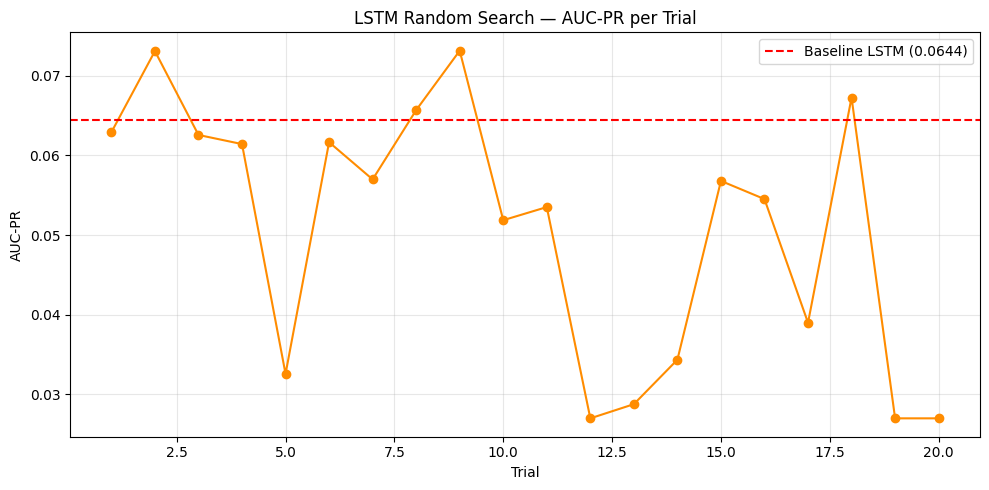


LSTM Parameter Correlation with AUC-PR:
auc_pr         1.0000
hidden_size    0.3028
dropout       -0.1094
lr            -0.3332
trial         -0.5385
num_layers    -0.8907
Name: auc_pr, dtype: float64
Epoch 1/1000 - Time: 2.77s - Train: 0.0347 - Val: 0.0239 - Val AUC-PR: 0.0549
___________________________________
Epoch 2/1000 - Time: 2.73s - Train: 0.0333 - Val: 0.0241 - Val AUC-PR: 0.0574
___________________________________
Epoch 3/1000 - Time: 2.78s - Train: 0.0328 - Val: 0.0241 - Val AUC-PR: 0.0579
___________________________________
Epoch 4/1000 - Time: 2.74s - Train: 0.0328 - Val: 0.0232 - Val AUC-PR: 0.0596
___________________________________
Epoch 5/1000 - Time: 2.75s - Train: 0.0327 - Val: 0.0215 - Val AUC-PR: 0.0569
___________________________________
Epoch 6/1000 - Time: 2.72s - Train: 0.0324 - Val: 0.0247 - Val AUC-PR: 0.0597
___________________________________
Epoch 7/1000 - Time: 2.72s - Train: 0.0325 - Val: 0.0251 - Val AUC-PR: 0.0577
___________________________________


c:\Users\Elias\Documents\SCANIA Component X\utils\trainer.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(save_path, map_location

In [32]:
# LSTM Search Results Plot
lstm_results_df = pd.DataFrame(lstm_results)

plt.figure(figsize=(10, 5))
plt.plot(lstm_results_df['trial'], lstm_results_df['auc_pr'], marker='o', color='darkorange')
plt.axhline(y=0.0644, color='red', linestyle='--', label='Baseline LSTM (0.0644)')
plt.xlabel('Trial')
plt.ylabel('AUC-PR')
plt.title('LSTM Random Search — AUC-PR per Trial')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation analysis
print("\nLSTM Parameter Correlation with AUC-PR:")
print(lstm_results_df.corr()['auc_pr'].sort_values(ascending=False).round(4))

# Best LSTM retrained and evaluated on val
best_lstm = utils.LSTMModel(
    input_size=INPUT_SIZE,
    hidden_size=best_lstm_params['hidden_size'],
    num_layers=best_lstm_params['num_layers'],
    dropout=best_lstm_params['dropout']
)
best_lstm_trainer = utils.BaseTrainer(best_lstm, lr=best_lstm_params['lr'], clip_grad=CLIP_GRAD)
best_lstm_trainer.fit(
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_path=MODEL_DIR / 'lstm_best.pt'
)
lstm_metrics, lstm_preds, lstm_probs = best_lstm_trainer.evaluate(X_val_seq, y_val_seq)

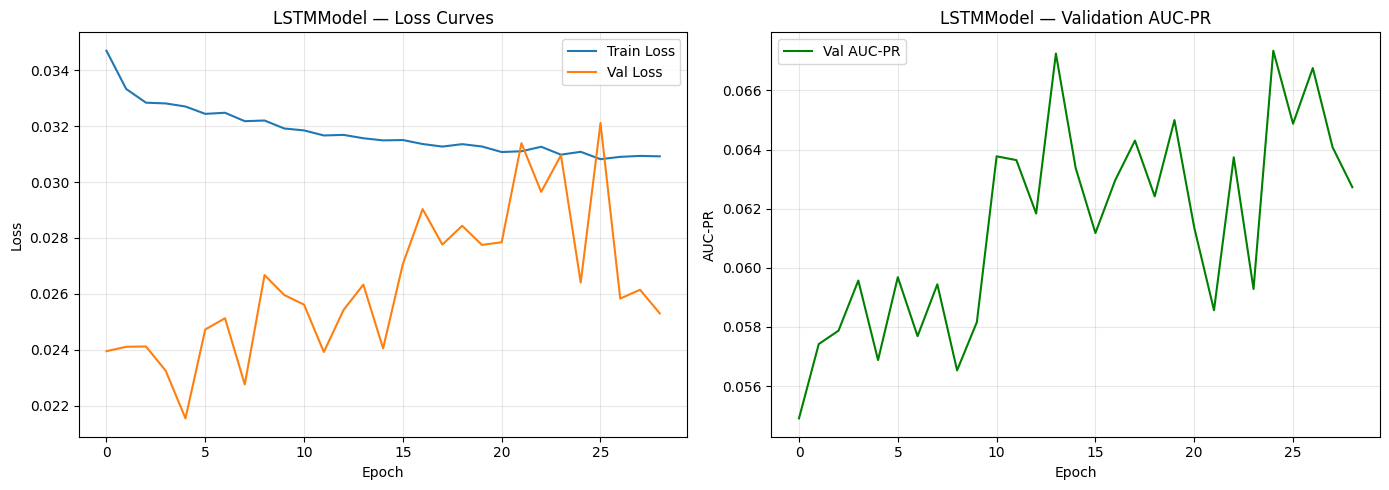

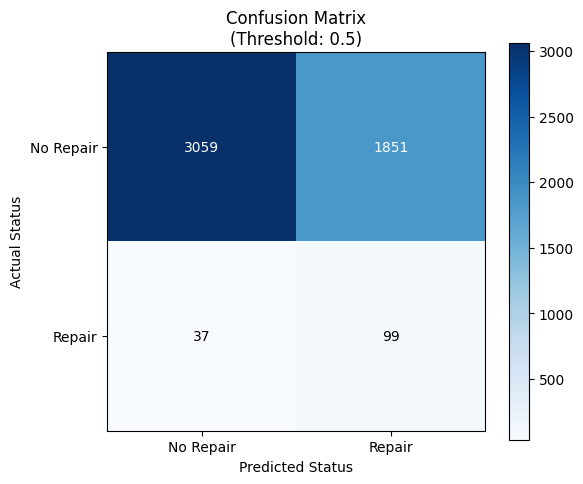

In [49]:
best_lstm_trainer.plot_history()
best_lstm_trainer.plot_cm(X_val_seq, y_val_seq)


### 5.1.2 - TCN

In [33]:
tcn_param_grid = {
    'num_channels': [32, 64],        
    'num_layers':   [2, 3, 4],       
    'kernel_size':  [3, 5, 7],
    'dropout':      [0.1, 0.2, 0.3, 0.4, 0.5],
    'lr':           [0.00001, 0.0001, 0.0005, 0.001, 0.005, 0.01],
}

N_ITER_TCN = 10

# TCN
best_tcn_params, best_tcn_auc_pr, tcn_results = utils.random_search(
    model_class=utils.TCNModel,
    param_grid=tcn_param_grid,
    model_kwargs_fn=lambda p: {
        'input_size':   INPUT_SIZE,
        'num_channels': p['num_channels'],
        'num_layers':   p['num_layers'],
        'kernel_size':  p['kernel_size'],
        'dropout':      p['dropout']
    },
    X_train=X_train_seq, y_train=y_train_seq,
    X_val=X_val_seq,     y_val=y_val_seq,
    n_iter=N_ITER_TCN,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_dir=MODEL_DIR,
    model_name='tcn',
    clip_grad=None
)


Trial 1/10: {'num_channels': 32, 'num_layers': 2, 'kernel_size': 7, 'dropout': 0.3, 'lr': 0.0001}
Epoch 1/1000 - Time: 18.12s - Train: 0.0440 - Val: 0.0260 - Val AUC-PR: 0.0353
___________________________________
Epoch 2/1000 - Time: 18.03s - Train: 0.0374 - Val: 0.0245 - Val AUC-PR: 0.0414
___________________________________
Epoch 3/1000 - Time: 18.02s - Train: 0.0351 - Val: 0.0244 - Val AUC-PR: 0.0461
___________________________________
Epoch 4/1000 - Time: 17.96s - Train: 0.0337 - Val: 0.0256 - Val AUC-PR: 0.0507
___________________________________
Epoch 5/1000 - Time: 18.19s - Train: 0.0328 - Val: 0.0269 - Val AUC-PR: 0.0508
___________________________________
Epoch 6/1000 - Time: 17.99s - Train: 0.0320 - Val: 0.0262 - Val AUC-PR: 0.0510
___________________________________
Epoch 7/1000 - Time: 18.03s - Train: 0.0311 - Val: 0.0279 - Val AUC-PR: 0.0520
___________________________________
Epoch 8/1000 - Time: 17.98s - Train: 0.0309 - Val: 0.0265 - Val AUC-PR: 0.0562
_________________

c:\Users\Elias\Documents\SCANIA Component X\utils\trainer.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(save_path, map_location

Trial 1 AUC-PR: 0.0616
New best tcn: {'num_channels': 32, 'num_layers': 2, 'kernel_size': 7, 'dropout': 0.3, 'lr': 0.0001} — AUC-PR: 0.0616

Trial 2/10: {'num_channels': 32, 'num_layers': 2, 'kernel_size': 7, 'dropout': 0.1, 'lr': 0.01}
Epoch 1/1000 - Time: 17.82s - Train: 0.0372 - Val: 0.0228 - Val AUC-PR: 0.0342
___________________________________
Epoch 2/1000 - Time: 17.98s - Train: 0.0358 - Val: 0.0251 - Val AUC-PR: 0.0480
___________________________________
Epoch 3/1000 - Time: 18.11s - Train: 0.0357 - Val: 0.0304 - Val AUC-PR: 0.0335
___________________________________
Epoch 4/1000 - Time: 18.14s - Train: 0.0360 - Val: 0.0231 - Val AUC-PR: 0.0337
___________________________________
Epoch 5/1000 - Time: 18.11s - Train: 0.0356 - Val: 0.0246 - Val AUC-PR: 0.0506
___________________________________
Epoch 6/1000 - Time: 17.87s - Train: 0.0364 - Val: 0.0214 - Val AUC-PR: 0.0546
___________________________________
Epoch 7/1000 - Time: 17.84s - Train: 0.0352 - Val: 0.0252 - Val AUC-PR: 0

c:\Users\Elias\Documents\SCANIA Component X\utils\trainer.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(save_path, map_location

Trial 2 AUC-PR: 0.0648
New best tcn: {'num_channels': 32, 'num_layers': 2, 'kernel_size': 7, 'dropout': 0.1, 'lr': 0.01} — AUC-PR: 0.0648

Trial 3/10: {'num_channels': 32, 'num_layers': 4, 'kernel_size': 5, 'dropout': 0.1, 'lr': 1e-05}
Epoch 1/1000 - Time: 46.20s - Train: 0.0524 - Val: 0.0315 - Val AUC-PR: 0.0286
___________________________________
Epoch 2/1000 - Time: 46.01s - Train: 0.0451 - Val: 0.0292 - Val AUC-PR: 0.0336
___________________________________
Epoch 3/1000 - Time: 46.48s - Train: 0.0427 - Val: 0.0282 - Val AUC-PR: 0.0363
___________________________________
Epoch 4/1000 - Time: 46.23s - Train: 0.0404 - Val: 0.0273 - Val AUC-PR: 0.0388
___________________________________
Epoch 5/1000 - Time: 47.20s - Train: 0.0391 - Val: 0.0269 - Val AUC-PR: 0.0405
___________________________________
Epoch 6/1000 - Time: 47.15s - Train: 0.0377 - Val: 0.0269 - Val AUC-PR: 0.0412
___________________________________
Epoch 7/1000 - Time: 46.79s - Train: 0.0370 - Val: 0.0268 - Val AUC-PR: 0.

...

Trial 8 AUC-PR: 0.0515

Trial 9/10: {'num_channels': 64, 'num_layers': 2, 'kernel_size': 5, 'dropout': 0.3, 'lr': 0.005}
Epoch 1/1000 - Time: 29.66s - Train: 0.0368 - Val: 0.0258 - Val AUC-PR: 0.0327
___________________________________
Epoch 2/1000 - Time: 30.05s - Train: 0.0348 - Val: 0.0226 - Val AUC-PR: 0.0560
___________________________________
Epoch 3/1000 - Time: 29.95s - Train: 0.0350 - Val: 0.0235 - Val AUC-PR: 0.0518
___________________________________
Epoch 4/1000 - Time: 29.59s - Train: 0.0343 - Val: 0.0321 - Val AUC-PR: 0.0371
___________________________________
Epoch 5/1000 - Time: 30.10s - Train: 0.0350 - Val: 0.0229 - Val AUC-PR: 0.0472
___________________________________
Epoch 6/1000 - Time: 30.09s - Train: 0.0342 - Val: 0.0264 - Val AUC-PR: 0.0562
___________________________________
Epoch 7/1000 - Time: 29.91s - Train: 0.0350 - Val: 0.0230 - Val AUC-PR: 0.0578
___________________________________
Epoch 8/1000 - Time: 29.66s - Train: 0.0342 - Val: 0.0253 - Val AUC-PR: 0.

c:\Users\Elias\Documents\SCANIA Component X\utils\trainer.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(save_path, map_location

Trial 9 AUC-PR: 0.0645

Trial 10/10: {'num_channels': 64, 'num_layers': 2, 'kernel_size': 7, 'dropout': 0.4, 'lr': 0.005}
Epoch 1/1000 - Time: 28.99s - Train: 0.0368 - Val: 0.0238 - Val AUC-PR: 0.0436
___________________________________
Epoch 2/1000 - Time: 29.46s - Train: 0.0352 - Val: 0.0234 - Val AUC-PR: 0.0382
___________________________________
Epoch 3/1000 - Time: 29.05s - Train: 0.0351 - Val: 0.0244 - Val AUC-PR: 0.0471
___________________________________
Epoch 4/1000 - Time: 29.28s - Train: 0.0352 - Val: 0.0242 - Val AUC-PR: 0.0367
___________________________________
Epoch 5/1000 - Time: 29.28s - Train: 0.0348 - Val: 0.0221 - Val AUC-PR: 0.0592
___________________________________
Epoch 6/1000 - Time: 29.05s - Train: 0.0345 - Val: 0.0234 - Val AUC-PR: 0.0549
___________________________________
Epoch 7/1000 - Time: 29.11s - Train: 0.0349 - Val: 0.0249 - Val AUC-PR: 0.0592
___________________________________
Epoch 8/1000 - Time: 29.19s - Train: 0.0344 - Val: 0.0228 - Val AUC-PR: 0

c:\Users\Elias\Documents\SCANIA Component X\utils\trainer.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(save_path, map_location

Trial 10 AUC-PR: 0.0592

Best tcn params: {'num_channels': 32, 'num_layers': 4, 'kernel_size': 5, 'dropout': 0.3, 'lr': 0.0005}
Best tcn AUC-PR: 0.0680


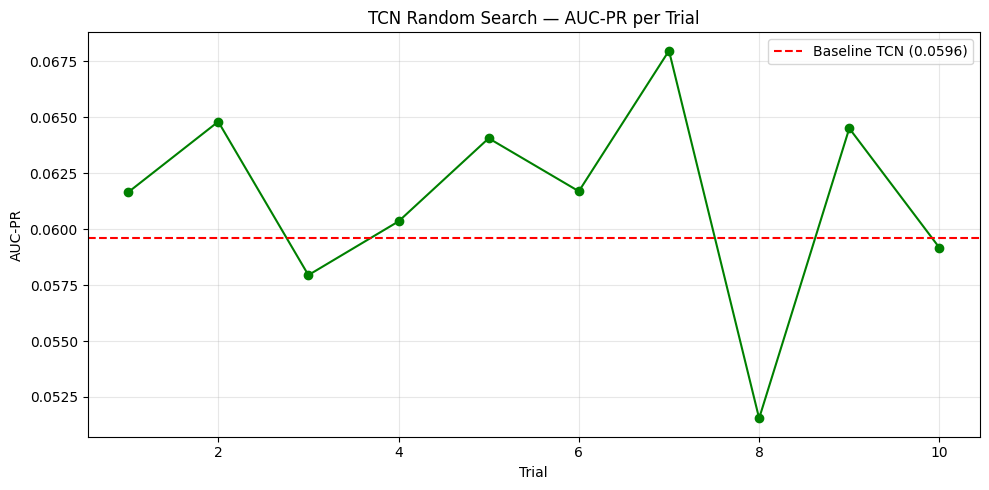


TCN Parameter Correlation with AUC-PR:
auc_pr          1.0000
dropout         0.3323
num_layers      0.3104
lr              0.2838
num_channels    0.0541
kernel_size     0.0051
trial          -0.1445
Name: auc_pr, dtype: float64
Epoch 1/1000 - Time: 46.94s - Train: 0.0452 - Val: 0.0268 - Val AUC-PR: 0.0503
___________________________________
Epoch 2/1000 - Time: 46.78s - Train: 0.0348 - Val: 0.0305 - Val AUC-PR: 0.0495
___________________________________
Epoch 3/1000 - Time: 46.61s - Train: 0.0329 - Val: 0.0238 - Val AUC-PR: 0.0535
___________________________________
Epoch 4/1000 - Time: 47.01s - Train: 0.0324 - Val: 0.0265 - Val AUC-PR: 0.0545
___________________________________
Epoch 5/1000 - Time: 46.74s - Train: 0.0320 - Val: 0.0264 - Val AUC-PR: 0.0553
___________________________________
Epoch 6/1000 - Time: 46.90s - Train: 0.0320 - Val: 0.0274 - Val AUC-PR: 0.0555
___________________________________
Epoch 7/1000 - Time: 46.97s - Train: 0.0319 - Val: 0.0259 - Val AUC-PR: 0.0586
_

c:\Users\Elias\Documents\SCANIA Component X\utils\trainer.py:183: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(save_path, map_location

___________________________________________
Standard Metrics:
Recall      : 0.7132
Precision   : 0.0482
F1          : 0.0903
AUC-ROC     : 0.7004
AUC-PR      : 0.0661


In [34]:
# TCN Search Results Plot
tcn_results_df = pd.DataFrame(tcn_results)

plt.figure(figsize=(10, 5))
plt.plot(tcn_results_df['trial'], tcn_results_df['auc_pr'], marker='o', color='green')
plt.axhline(y=0.0596, color='red', linestyle='--', label='Baseline TCN (0.0596)')
plt.xlabel('Trial')
plt.ylabel('AUC-PR')
plt.title('TCN Random Search — AUC-PR per Trial')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation analysis
print("\nTCN Parameter Correlation with AUC-PR:")
print(tcn_results_df.corr()['auc_pr'].sort_values(ascending=False).round(4))

# Best TCN retrained and evaluated on val
best_tcn = utils.TCNModel(
    input_size=INPUT_SIZE,
    num_channels=best_tcn_params['num_channels'],
    num_layers=best_tcn_params['num_layers'],
    kernel_size=best_tcn_params['kernel_size'],
    dropout=best_tcn_params['dropout']
)
best_tcn_trainer = utils.BaseTrainer(best_tcn, lr=best_tcn_params['lr'], clip_grad=None)
best_tcn_trainer.fit(
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_path=MODEL_DIR / 'tcn_best.pt'
)
tcn_metrics, tcn_preds, tcn_probs = best_tcn_trainer.evaluate(X_val_seq, y_val_seq)

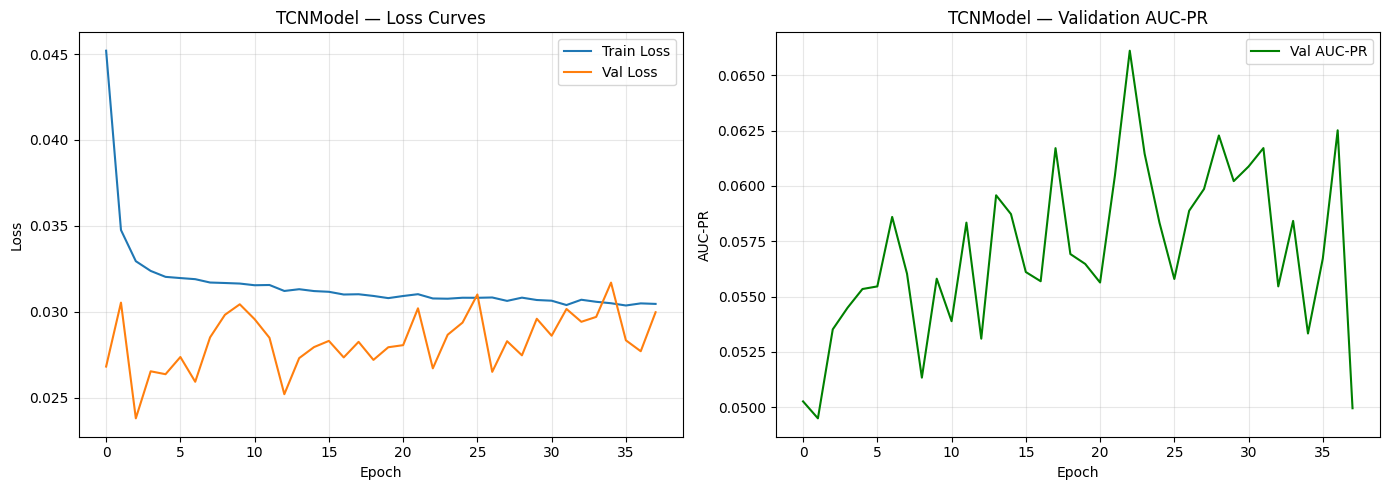

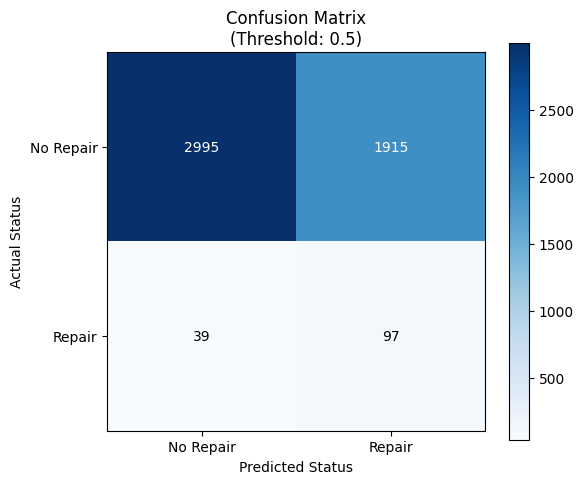

In [48]:
best_tcn_trainer.plot_history()
best_tcn_trainer.plot_cm(X_val_seq, y_val_seq)

## 5.2 - Randomized Search on XGBoost
XGBoost on the other hand, was made using Sklearn which means we can use the built in function `RandomizedSearchCV` instead.

In [42]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth':    [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':    [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=SEED, eval_metric='aucpr'),
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring='average_precision',
    cv=3,
    random_state=SEED,
    verbose=1
)
xgb_search.fit(X_resampled, y_resampled)
print(f"Best XGB params: {xgb_search.best_params_}")
print(f"Best XGB AUC-PR: {xgb_search.best_score_:.4f}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best XGB params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best XGB AUC-PR: 0.7946


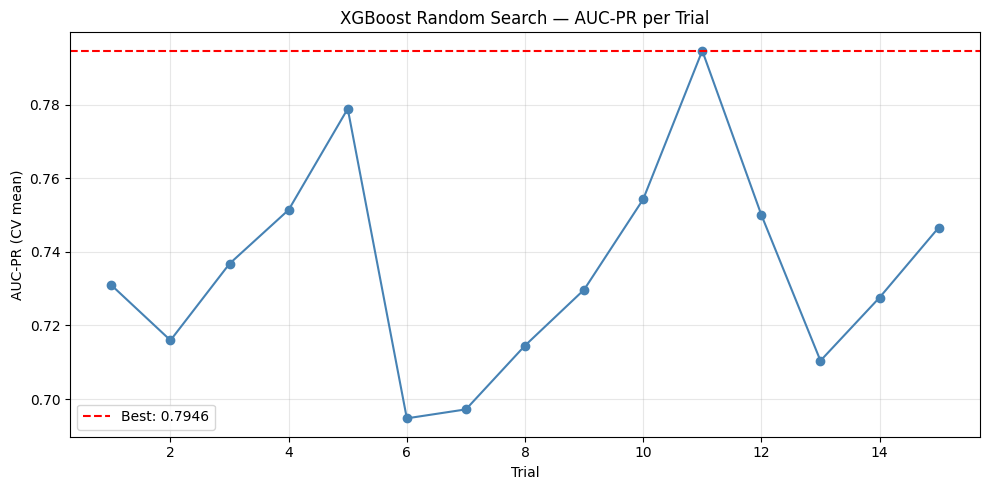


Correlation with AUC-PR:
auc_pr              1.0000
n_estimators        0.8039
learning_rate       0.7346
colsample_bytree    0.7064
max_depth           0.1019
subsample          -0.2759
Name: auc_pr, dtype: float64


In [43]:
# Results DataFrame
xgb_results = pd.DataFrame(xgb_search.cv_results_)

# Plot 1 — AUC-PR per trial
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(xgb_results)+1), xgb_results['mean_test_score'], marker='o', color='steelblue')
plt.axhline(y=xgb_search.best_score_, color='red', linestyle='--', label=f'Best: {xgb_search.best_score_:.4f}')
plt.xlabel('Trial')
plt.ylabel('AUC-PR (CV mean)')
plt.title('XGBoost Random Search — AUC-PR per Trial')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2 — Parameter importance via correlation
params_df = pd.DataFrame(xgb_results['params'].tolist())
params_df['auc_pr'] = xgb_results['mean_test_score'].values
print("\nCorrelation with AUC-PR:")
print(params_df.corr()['auc_pr'].sort_values(ascending=False).round(4))

In [44]:
best_xgb = XGBClassifier(
    random_state=SEED,
    eval_metric='aucpr',
    **xgb_search.best_params_
)
best_xgb.fit(X_resampled, y_resampled)
smote_xgb_pred = best_xgb.predict(X_val_embedded)
smote_xgb_prob = best_xgb.predict_proba(X_val_embedded)[:, 1]

smote_xgb_metrics = {
    'Recall': recall_score(y_val_seq, smote_xgb_pred),
    'Precision': precision_score(y_val_seq, smote_xgb_pred),
    'F1': f1_score(y_val_seq, smote_xgb_pred),
    'AUC-ROC': roc_auc_score(y_val_seq, smote_xgb_prob),
    'AUC-PR': average_precision_score(y_val_seq, smote_xgb_prob),
}
print("\nSMOTE + XGBoost:")
for k, v in smote_xgb_metrics.items():
    print(f"  {k:12s}: {v:.4f}")



SMOTE + XGBoost:
  Recall      : 0.6176
  Precision   : 0.0325
  F1          : 0.0617
  AUC-ROC     : 0.5905
  AUC-PR      : 0.0364


## 5.3 - Final Comparison

    Model  Recall  Precision     F1  AUC-ROC  AUC-PR
       LR  0.9338     0.0336 0.0648   0.7160  0.0645
     LSTM  0.7279     0.0508 0.0949   0.7028  0.0672
      TCN  0.7132     0.0482 0.0903   0.7004  0.0661
 SMOTE+LR  0.9265     0.0342 0.0659   0.6558  0.0424
SMOTE+XGB  0.7279     0.0351 0.0670   0.6207  0.0406


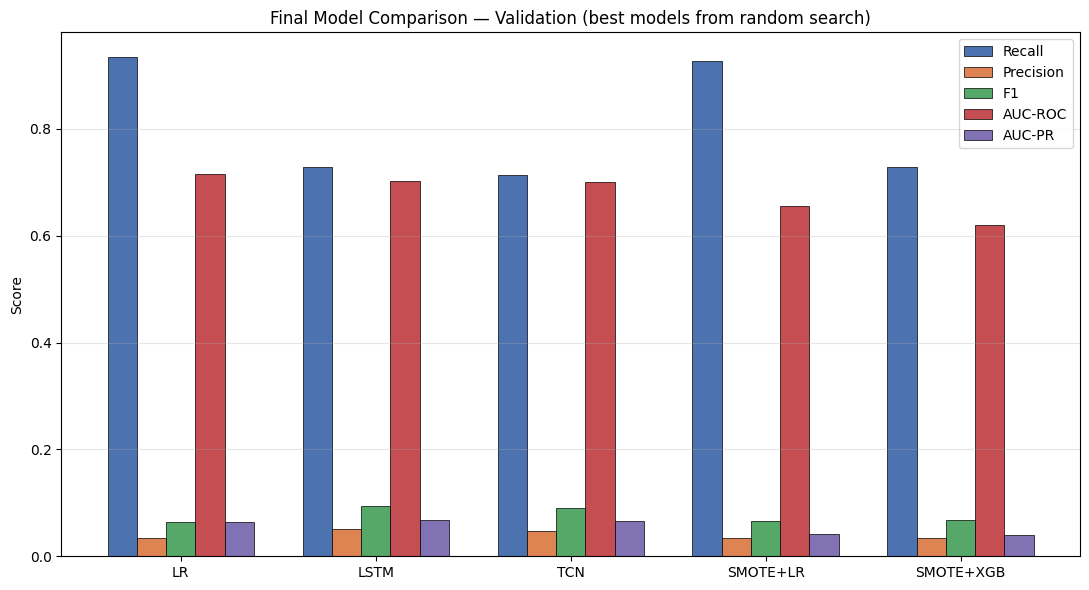

In [ ]:
# val labels for binary metrics
val_labels_full = pd.read_csv(PROJECT_ROOT / 'Data' / 'validation_labels.csv').set_index('vehicle_id')['class_label']

def metrics_at_05(name, probs, ids):
    y_class = val_labels_full.loc[ids].values
    y_bin = (y_class > 0).astype(int)
    pred = (probs >= 0.5).astype(int)
    return {
        'Model': name,
        'Recall': recall_score(y_bin, pred, zero_division=0),
        'Precision': precision_score(y_bin, pred, zero_division=0),
        'F1': f1_score(y_bin, pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_bin, probs),
        'AUC-PR': average_precision_score(y_bin, probs),
    }

results = []

# LR
_, p = get_lr_predictions(lr_model, X_val_lr)
results.append(metrics_at_05('LR', p, X_val_lr.index.values))

# LSTM (best from random search)
_, p = best_lstm_trainer.predict(X_val_seq)
results.append(metrics_at_05('LSTM', p, val_seq_ids))

# TCN (best from random search)
_, p = best_tcn_trainer.predict(X_val_seq)
results.append(metrics_at_05('TCN', p, val_seq_ids))

# SMOTE+LR
p = smote_lr.predict_proba(X_val_embedded)[:, 1]
results.append(metrics_at_05('SMOTE+LR', p, val_seq_ids))

# SMOTE+XGB
p = smote_xgb.predict_proba(X_val_embedded)[:, 1]
results.append(metrics_at_05('SMOTE+XGB', p, val_seq_ids))

df = pd.DataFrame(results)
df_disp = df.copy()
for c in ['Recall', 'Precision', 'F1', 'AUC-ROC', 'AUC-PR']:
    df_disp[c] = df_disp[c].round(4)
print(df_disp.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(df))
w = 0.15
metrics = ['Recall', 'Precision', 'F1', 'AUC-ROC', 'AUC-PR']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
for i, (m, c) in enumerate(zip(metrics, colors)):
    ax.bar(x + (i - 2) * w, df[m], w, label=m, color=c, edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(df['Model'])
ax.set_ylabel('Score')
ax.set_title('Final Model Comparison — Best models from random search, threshold=0.5')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Section 6 -  Model, Label and Data Save

## 5.2 - Saving Models, Data and Parameters

In [ ]:
SAVE = False 

### 5.2.1 - Model Save

In [86]:
if SAVE:
    # Save baseline LR
    save_lr_model(lr_model, MODEL_DIR / 'lr_model.joblib')
    save_lr_predictions(X_val_lr, pred, prob, PREDICTION_DIR / 'lr_val_predictions.csv')

    # Save LSTM
    lstm_trainer.save(
        val_seq_ids,
        X_val_seq, MODEL_DIR / 'lstm_best.pt',
        PREDICTION_DIR / 'lstm_val_predictions.csv'
    )

    # Save TCN
    tcn_trainer.save(
        val_seq_ids,
        X_val_seq, MODEL_DIR / 'tcn_best.pt',
        PREDICTION_DIR / 'tcn_val_predictions.csv'
    )

    # Save SMOTE models
    joblib.dump(smote_lr, MODEL_DIR / 'smote_lr_model.joblib')
    joblib.dump(smote_xgb, MODEL_DIR / 'smote_xgb_model.joblib')

    # Save sktime TapNet encoder
    joblib.dump(tapnet_model, MODEL_DIR / 'tapnet_sktime.joblib')

    # Save SMOTE predictions
    pd.DataFrame({
        'vehicle_id': list(val_seq_ids),
        'probability': smote_lr_probs_val,
        'binary_prediction': smote_lr_preds_val
    }).to_csv(PREDICTION_DIR / 'smote_lr_val_predictions.csv', index=False)

    pd.DataFrame({
        'vehicle_id': list(val_seq_ids),
        'probability': smote_xgb_probs_val,
        'binary_prediction': smote_xgb_preds_val
    }).to_csv(PREDICTION_DIR / 'smote_xgb_val_predictions.csv', index=False)

    print("All models saved.")

    # Verify all prediction files match vehicle ID order
    lr_preds = pd.read_csv(PREDICTION_DIR / 'lr_val_predictions.csv')
    lstm_preds = pd.read_csv(PREDICTION_DIR / 'lstm_val_predictions.csv')
    tcn_preds = pd.read_csv(PREDICTION_DIR / 'tcn_val_predictions.csv')
    smote_lr_preds = pd.read_csv(PREDICTION_DIR / 'smote_lr_val_predictions.csv')
    smote_xgb_preds = pd.read_csv(PREDICTION_DIR / 'smote_xgb_val_predictions.csv')

    assert list(lstm_preds['vehicle_id']) == list(tcn_preds['vehicle_id']), "LSTM vs TCN mismatch"
    assert list(lstm_preds['vehicle_id']) == list(smote_lr_preds['vehicle_id']), "LSTM vs SMOTE-LR mismatch"
    assert list(lstm_preds['vehicle_id']) == list(smote_xgb_preds['vehicle_id']), "LSTM vs SMOTE-XGB mismatch"

    print("All vehicle ID orders match!")

Saving the model...
Model saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Models\lr_model.joblib
Saving the DataFrame...
DataFrame saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Predictions\lr_val_predictions.csv
Model saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Models\lstm_best.pt
Predictions saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Predictions\lstm_val_predictions.csv
Model saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Models\tcn_best.pt
Predictions saved to c:\Users\Elias\Documents\SCANIA Component X\Results\Predictions\tcn_val_predictions.csv
All models saved.
All vehicle ID orders match!


### 5.2.2 - Augmented Data Saving

In [ ]:
if SAVE:
    # Save embeddings
    np.save(PREDICTION_DIR / 'X_train_embedded.npy', X_train_emb)
    np.save(PREDICTION_DIR / 'X_val_embedded.npy', X_val_emb)
    np.save(PREDICTION_DIR / 'X_test_embedded.npy', X_test_emb)

    # Save SMOTE augmented data
    np.save(PREDICTION_DIR / 'X_resampled.npy', X_resampled)
    np.save(PREDICTION_DIR / 'y_resampled.npy', y_resampled)

    np.save(PREDICTION_DIR / 'X_test_embedded.npy', X_test_emb)


    print("All embeddings and augmented data saved.")

All embeddings and augmented data saved.


### 5.2.3 -  Saving the HyperParameters

In [89]:
import json

if SAVE:

    hyperparams = {
        'INPUT_SIZE': INPUT_SIZE,
        'SEQ_LEN': SEQ_LEN,
        'LSTM': {
            'hidden_size': HIDDEN_SIZE,
            'num_layers': NUM_LAYERS,
            'dropout': DROPOUT,
            'learning_rate': LEARNING_RATE,
            'clip_grad': CLIP_GRAD,
        },
        'TCN': {
            'num_channels': TCN_NUM_CHANNELS,
            'num_layers': TCN_NUM_LAYERS,
            'kernel_size': TCN_KERNEL_SIZE,
            'dropout': TCN_DROPOUT,
            'learning_rate': TCN_LEARNING_RATE,
        }
    }

    with open(MODEL_DIR / 'hyperparams.json', 'w') as f:
        json.dump(hyperparams, f)
    print("Hyperparameters saved.")

Hyperparameters saved.


In [94]:
import json
costs_summary = {name: {'threshold': t, 'val_cost': vc, 'test_cost': tc} 
                 for name, (t, vc, tc) in results.items()}
with open(PREDICTION_DIR / 'cost_results.json', 'w') as f:
    json.dump(costs_summary, f)